# Loading the Libraies that are require for the Analysis

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"C:\Users\Administrator\Desktop\Comprehensive Restaurant Analysis using python\Notebook\Data\Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


Checking for the any Null values in the Dataset or missing values 

In [4]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

From above analysis find that there no missing or null values present

In [5]:
# Finding the Dupliacted values 
df.duplicated().sum()

np.int64(0)

There is no dupliacted values means that no repeated values in the Dataset.

In [6]:
# Describing the Dataset for Neumerical columns
df.describe() 

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


# Primarly Analysis about the Cuisines 

Determining  the top three most common cuisines in the dataset.

In [7]:
Cuisines = df['Cuisines'].value_counts().head(3)
Cuisines

Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Name: count, dtype: int64

Calculate the percentage of restaurants that serve each of the top cuisines.

In [8]:
Cuisines = df['Cuisines'].value_counts().head(3)

len(df) # for calculating the Percentage need the total 

percentage = (Cuisines / len(df)) * 100
percentage


Cuisines
North Indian             9.800021
North Indian, Chinese    5.350225
Chinese                  3.706418
Name: count, dtype: float64

# City related analysis 

Identify the city with the highest number of restaurants in the dataset

In [9]:
city = df['City'].value_counts().head(1)
city

City
New Delhi    5473
Name: count, dtype: int64

Calculate the average rating for restaurants in each city.

In [10]:
rating_average = df.groupby('City')['Aggregate rating']
rating = rating_average.mean()
print("the Average rating restaurent in each city:")
print(rating)

the Average rating restaurent in each city:
City
Abu Dhabi          4.300000
Agra               3.965000
Ahmedabad          4.161905
Albany             3.555000
Allahabad          3.395000
                     ...   
Weirton            3.900000
Wellington City    4.250000
Winchester Bay     3.200000
Yorkton            3.300000
��stanbul          4.292857
Name: Aggregate rating, Length: 141, dtype: float64


Determine the city with the highest average rating.

In [11]:
rating_average = df.groupby('City')['Aggregate rating']
high_average = rating_average.mean().head(1)
high_average

City
Abu Dhabi    4.3
Name: Aggregate rating, dtype: float64

# Analyzing of the Price Range Distribution in restuauants and city.

Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants.

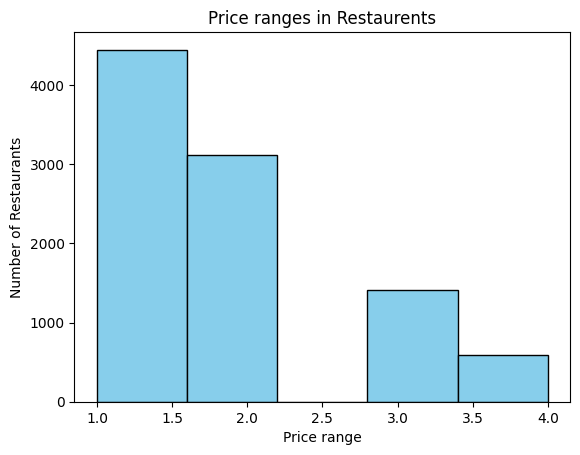

In [12]:
Price_ranges = df['Price range']
Price_ranges
plt.hist(Price_ranges,bins=5, color='skyblue', edgecolor='black')
plt.xlabel('Price range')
plt.ylabel('Number of Restaurants')
plt.title('Price ranges in Restaurents')
plt.show()

Calculate the percentage of restaurants in each price range category.

In [13]:
percentage_price = df['Price range'].value_counts(normalize=True)*100
percentage_price

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: proportion, dtype: float64

# Online Delivery related analysis.

Determine the percentage of restaurants that offer online delivery.

In [14]:
online_deli_percent = df['Has Online delivery'].value_counts(normalize=True)*100 # noramalize=True -> it takes most frequency value in the respect coloumn
online_deli_percent

Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64

From above we can easily understanding that 74.33% restuarants offering the Online delivery for Customers.



# Analysis of the Resturant Ratings.

Analyze the distribution of aggregate ratings and determine the most common rating range.

Text(0.5, 1.0, 'Distribution of aggregate ratings among the various Restaurants')

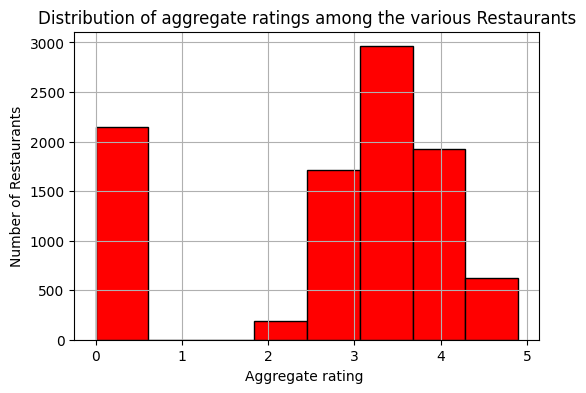

In [15]:
# for analyzing the distrubution of we need plot histogram
plt.figure(figsize=(6,4))
df['Aggregate rating'].hist(bins=8,color ='red',edgecolor = 'black')
plt.xlabel('Aggregate rating ')
plt.ylabel('Number of Restaurants')
plt.title('Distribution of aggregate ratings among the various Restaurants')

Determine the most common rating range.

In [16]:
most_comman_rating = df['Aggregate rating'].median()
print("The most comman rating range:",most_comman_rating)

The most comman rating range: 3.2


The most comman rating across all the restauants is 3.2 

Calculate the average number of votes received by restaurants.

In [17]:
a = df['Votes'].count()
print('The total votes:',a)
vote_average = df['Votes'].mean()
print("the average voting rate is :",vote_average)

The total votes: 9551
the average voting rate is : 156.909747670401


# Analysis of the Restaurant Chains.

Identify if there are any restaurant chains present in the dataset.

In [18]:
# Check if 'Restaurant Name' column exists
if 'Restaurant Name' in df.columns:
    # Identify restaurant chains (same name, multiple locations)
    restaurant_chain_counts = df['Restaurant Name'].value_counts()

    # Display restaurants that appear more than once (indicating chains)
    chains = restaurant_chain_counts[restaurant_chain_counts > 1]
    
    if not chains.empty:
        print("Restaurant Chains Found:")
        print(chains)
    else:
        print("No restaurant chains found in the dataset.")
else:
    print("The dataset doesn't contain a 'Restaurant Name' column.")




Restaurant Chains Found:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
                    ..
San Carlo            2
Gymkhana             2
Dishoom              2
Timboo Cafe          2
D�_vero��lu          2
Name: count, Length: 734, dtype: int64


Analyze the ratings and popularity of different restaurant chains.

In [19]:
df['restaurant name'] = df['Restaurant Name'].str.lower()

chain_ratings = df.groupby('restaurant name').agg({
    'Aggregate rating': 'mean',
    'Votes': 'sum'
}).reset_index()

popular_chains = chain_ratings.sort_values(by='Votes', ascending=False).head(5)


highest_rated_chains = chain_ratings.sort_values(by='Aggregate rating', ascending=False).head(5) 

print("Top 5 Most Popular Chains:")
print(popular_chains[['restaurant name', 'Votes']])

print("\nTop 5 Highest-Rated Chains:")

print(highest_rated_chains[['restaurant name', 'Aggregate rating']])


Top 5 Most Popular Chains:
                restaurant name  Votes
653             barbeque nation  28142
124   ab's - absolute barbecues  13400
6939                       toit  10934
779                   big chill  10853
2291                 farzi cafe  10098

Top 5 Highest-Rated Chains:
                    restaurant name  Aggregate rating
7420  zolocrust - hotel clarks amer               4.9
7337                yellow dog eats               4.9
1804         cube - tasting kitchen               4.9
4068       mazzaro's italian market               4.9
4034                  marukame udon               4.9


# Analysis of the Restaurant Reviews.

Analyze the text reviews to identify the most common positive and negative keywords.

In [20]:
text_reviews = df['Rating text'].value_counts()
text_reviews

Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

From the Above observered that The most Postivie Keyword is "Average" ('An "average" review of a restaurant is generally considered positive') with the count of "3737" and another positive Keyword is "Good" with count of "2100".

The most negative keyword is "Not Rated"(A "not rated" review of a restaurant is generally considered neutral or leaning towards negative) with Count of "2148" another Negative is "Poor" with count of "186".

### Positive = Average
### Negative = Poor

Calculate the average length of reviews and explore if there is a relationship between review length and rating.

In [21]:
df['Review length'] = df['Rating text'].str.len()
average_review = df['Review length'].mean()
print('The average length odf reviews:',average_review)

The average length odf reviews: 7.020730813527379


Analyzing the relationship between the reviww and rating.

In [22]:
correlation = df[['Review length','Aggregate rating']].corr()
correlation

,Review length,Aggregate rating
Review length,1.000000,-0.478885
Aggregate rating,-0.478885,1.000000


For that realtion for the better vizulations ploting the heatmap.

<Axes: >

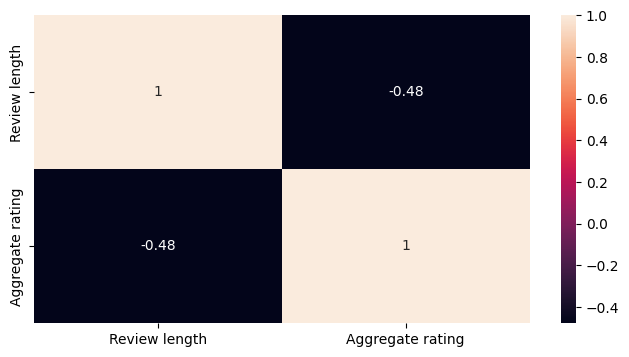

In [23]:
plt.figure(figsize=(8,4))
sns.heatmap(data=correlation,annot=True)

# Analysis of the Votes Analysis.

Identify the restaurants with the highest number of votes.

In [24]:
votes = df.groupby('Restaurant Name')['Votes'].max()
Highest_votes = votes.sort_values(ascending=False)
Highest_votes.head(5)

Restaurant Name
Toit                         10934
Truffles                      9667
Hauz Khas Social              7931
Peter Cat                     7574
AB's - Absolute Barbecues     6907
Name: Votes, dtype: int64

The highest voted restaurants are Toit,Truffles,Hauz Khas Social,Peter Cat,AB's - Absolute Barbecues.

In [25]:
votes = df.groupby('Restaurant Name')['Votes'].min()
Lowest_votes = votes.sort_values(ascending=True)
Lowest_votes.head(5)

Restaurant Name
Cafe Lounge     0
Cafe Krisa      0
Cafe Hot Pot    0
Cafe Point      0
Cafe Treat      0
Name: Votes, dtype: int64

Above listed restaurants are the low voting restaurants.

Analyze if there is a correlation between the number of votes and the rating of a restaurant.

In [26]:
relation = df[['Votes','Aggregate rating']].corr()
relation

,Votes,Aggregate rating
Votes,1.000000,0.313691
Aggregate rating,0.313691,1.000000


For the better understanding ploting the Heatmap.


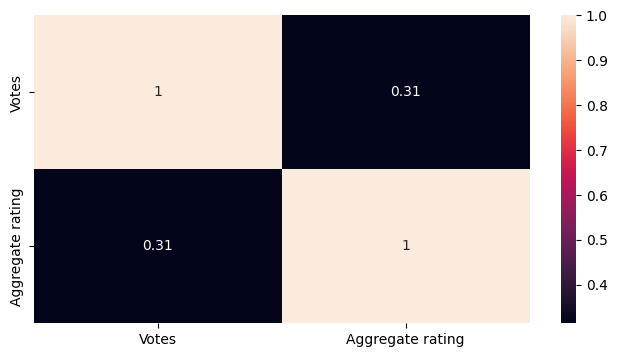

In [27]:
plt.figure(figsize=(8,4))
sns.heatmap(data=relation,annot=True)
plt.show()

# Analysis of the Price Range vs. Online Delivery

 Analyze if there is a relationship between the price range and the availability of online delivery.

In [28]:
df['Has Online delivery'].unique()

array(['No', 'Yes'], dtype=object)

In [29]:
# convert the Has Online delivery categorical values into the neumerical values 
df['Online Delivery'] = df['Has Online delivery'].map({'Yes':1,'No':0})
df['Online Delivery']

0       0
1       0
2       0
3       0
4       0
       ..
9546    0
9547    0
9548    0
9549    0
9550    0
Name: Online Delivery, Length: 9551, dtype: int64

In [30]:
Online = df[['Price range','Online Delivery']].corr()
Online

,Price range,Online Delivery
Price range,1.000000,0.077918
Online Delivery,0.077918,1.000000


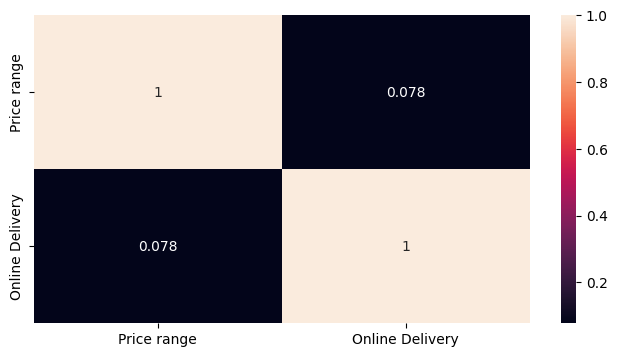

In [31]:
plt.figure(figsize=(8,4))
sns.heatmap(data=Online,annot=True)
plt.show()

Determine if higher-priced restaurants are more likely to offer these services.

In [32]:
higher_priced_restaurants = df.groupby('Restaurant Name')['Price range'].max()
higher_priced_restaurants.sort_values(ascending=False).head(10)

Restaurant Name
Olive                                   4
The Refinery Singapore                  4
Colony                                  4
Fat Fish                                4
Elan - The Lodhi                        4
Floriditas                              4
The Old School Brew House               4
10 Downing Street                       4
New Koto                                4
Neung Roi - Radisson Blu Plaza Delhi    4
Name: Price range, dtype: int64

Here the 4 means these are Premimum rates price